# 🧠⚡ EEG Epilepsia — Detección de crisis con CHB-MIT

**Dataset:** CHB-MIT Scalp EEG — PhysioNet  
**Pacientes:** 23 sujetos pediátricos con epilepsia focal refractaria  
**Objetivo:** Clasificar segmentos EEG como:
- `interictal` — entre crisis (estado basal)
- `ictal` — durante la crisis
- `preictal` — minutos antes de la crisis *(el más valioso clínicamente)*

**Relevancia clínica:**  
Un sistema que detecte el estado preictal con 10-30 minutos de antelación  
podría avisar al paciente antes de que ocurra la crisis.

```bash
pip install mne scikit-learn matplotlib numpy scipy pyedflib
```

> **Nota:** El CHB-MIT no está en el repositorio de MNE como el EEGBCI.  
> Lo descargamos directamente de PhysioNet (~1 GB para un paciente).

## 1. Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')
import os, urllib.request, time

import mne
from mne.io import read_raw_edf

from scipy.signal import welch, butter, filtfilt
from scipy.integrate import simpson

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.metrics import (classification_report, confusion_matrix,
                              ConfusionMatrixDisplay, roc_curve, auc)
from sklearn.utils import resample

mne.set_log_level('WARNING')
print('✅ Imports OK')

✅ Imports OK


## 2. Descarga del dataset CHB-MIT

Usamos el **paciente chb01** — el más estudiado en la literatura.  
Tiene 23 archivos EDF con 7 crisis anotadas.

Los archivos de anotaciones (`.seizures`) contienen los timestamps
exactos de inicio y fin de cada crisis, verificados por neurólogos.

In [2]:
DATA_DIR  = os.path.expanduser('~/chbmit_data/chb01')
os.makedirs(DATA_DIR, exist_ok=True)

BASE_URL  = 'https://physionet.org/files/chbmit/1.0.0/chb01/'

# Archivos con crisis anotadas para chb01
# (solo descargamos los que tienen crisis + algunos sin crisis)
FILES_WITH_SEIZURES = {
    'chb01_03.edf': [(2996, 3036)],          # crisis: 2996s-3036s
    'chb01_04.edf': [(1467, 1494)],
    'chb01_15.edf': [(1732, 1772)],
    'chb01_16.edf': [(1015, 1066)],
    'chb01_18.edf': [(1720, 1810)],
}
FILES_WITHOUT = ['chb01_01.edf', 'chb01_02.edf']
ALL_FILES = list(FILES_WITH_SEIZURES.keys()) + FILES_WITHOUT

def download_file(fname):
    fpath = os.path.join(DATA_DIR, fname)
    if os.path.exists(fpath):
        print(f'  ✓ {fname} (ya descargado)')
        return True
    url = BASE_URL + fname
    print(f'  📥 Descargando {fname}...', end=' ', flush=True)
    try:
        urllib.request.urlretrieve(url, fpath)
        size_mb = os.path.getsize(fpath) / 1e6
        print(f'{size_mb:.0f} MB')
        return True
    except Exception as e:
        print(f'Error: {e}')
        return False

print('📥 Descargando archivos CHB-MIT (chb01)...')
print('   Esto puede tardar varios minutos (~100-150 MB por archivo)\n')
for fname in ALL_FILES:
    download_file(fname)

print('\n✅ Descarga completa')

📥 Descargando archivos CHB-MIT (chb01)...
   Esto puede tardar varios minutos (~100-150 MB por archivo)

  ✓ chb01_03.edf (ya descargado)
  ✓ chb01_04.edf (ya descargado)
  ✓ chb01_15.edf (ya descargado)
  ✓ chb01_16.edf (ya descargado)
  ✓ chb01_18.edf (ya descargado)
  ✓ chb01_01.edf (ya descargado)
  ✓ chb01_02.edf (ya descargado)

✅ Descarga completa


## 3. Carga y visualización de una crisis

Cargamos `chb01_03.edf` — contiene una crisis entre los segundos 2996 y 3036.

📊 chb01_03.edf
   Canales:    23
   Frecuencia: 256 Hz
   Duración:   60.0 min
   Crisis:     2996s → 3036s  (40s de duración)
   Canales EEG: ['FP1-F7', 'F7-T7', 'T7-P7', 'P7-O1', 'FP1-F3']...


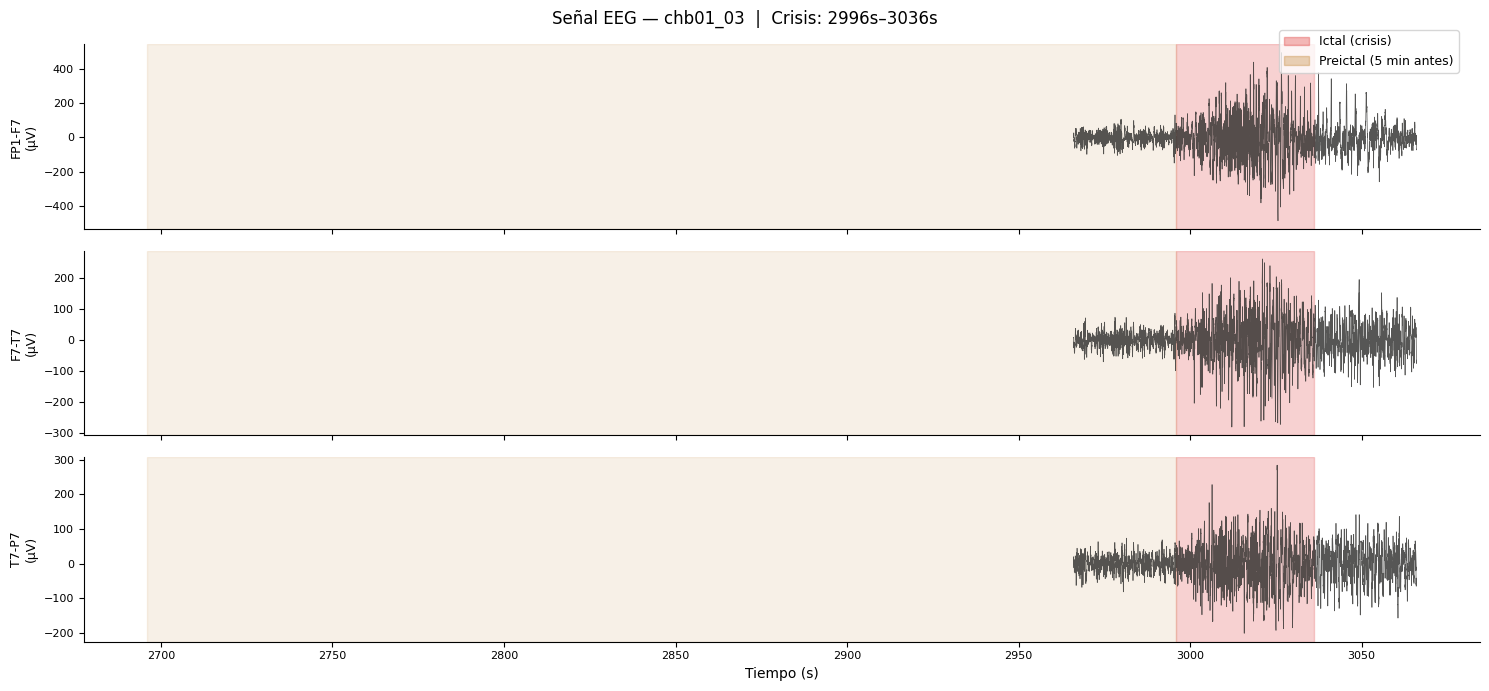

💡 Observa cómo cambia la amplitud y frecuencia durante la crisis


In [3]:
# Cargar archivo con crisis
fpath = os.path.join(DATA_DIR, 'chb01_03.edf')
raw   = read_raw_edf(fpath, preload=True, verbose=False)

FS      = int(raw.info['sfreq'])
N_CH    = raw.info['nchan']
SEIZURE = FILES_WITH_SEIZURES['chb01_03.edf'][0]  # (2996, 3036)

print(f'📊 chb01_03.edf')
print(f'   Canales:    {N_CH}')
print(f'   Frecuencia: {FS} Hz')
print(f'   Duración:   {raw.times[-1]/60:.1f} min')
print(f'   Crisis:     {SEIZURE[0]}s → {SEIZURE[1]}s  ({SEIZURE[1]-SEIZURE[0]}s de duración)')
print(f'   Canales EEG: {raw.ch_names[:5]}...')

# Preprocesar
raw.filter(0.5, 50., fir_design='firwin')
raw.notch_filter(50., fir_design='firwin')

# Visualizar 3 canales: antes, durante y después de la crisis
ch_plot  = raw.ch_names[:3]   # primeros 3 canales
WIN_SIZE = 30   # segundos a mostrar
t_start  = SEIZURE[0] - WIN_SIZE   # 30s antes de la crisis
t_end    = SEIZURE[1] + WIN_SIZE   # 30s después

fig, axes = plt.subplots(len(ch_plot), 1, figsize=(15, 7), sharex=True)
fig.suptitle(f'Señal EEG — chb01_03  |  Crisis: {SEIZURE[0]}s–{SEIZURE[1]}s',
             fontsize=12)

for ax, ch in zip(axes, ch_plot):
    idx  = raw.ch_names.index(ch)
    data = raw.get_data(picks=[idx])[0] * 1e6  # µV
    t    = raw.times
    mask = (t >= t_start) & (t <= t_end)
    ax.plot(t[mask], data[mask], lw=0.5, color='#2c2c2a', alpha=0.8)

    # Marcar la crisis
    ax.axvspan(SEIZURE[0], SEIZURE[1],
               alpha=0.25, color='#E24B4A', label='Crisis (ictal)')
    # Marcar zona preictal (5 min antes)
    ax.axvspan(SEIZURE[0]-300, SEIZURE[0],
               alpha=0.1, color='#BA7517', label='Preictal (5 min)')

    ax.set_ylabel(f'{ch}\n(µV)', fontsize=9)
    ax.tick_params(labelsize=8)
    ax.spines[['top','right']].set_visible(False)

axes[-1].set_xlabel('Tiempo (s)', fontsize=10)

# Leyenda global
red_patch    = mpatches.Patch(color='#E24B4A', alpha=0.4, label='Ictal (crisis)')
orange_patch = mpatches.Patch(color='#BA7517', alpha=0.3, label='Preictal (5 min antes)')
fig.legend(handles=[red_patch, orange_patch],
           loc='upper right', fontsize=9, bbox_to_anchor=(0.98, 0.96))

plt.tight_layout()
plt.savefig('epilepsy_raw_seizure.png', dpi=120, bbox_inches='tight')
plt.show()
print('💡 Observa cómo cambia la amplitud y frecuencia durante la crisis')

## 4. Extracción de segmentos: ictal, preictal, interictal

**Definiciones clínicas que usamos:**
- **Ictal**: durante la crisis
- **Preictal**: 5 minutos antes del inicio de la crisis
- **Interictal**: al menos 1 hora alejado de cualquier crisis

Ventanas de 10 segundos con 50% de solapamiento.

In [4]:
WINDOW_SEC   = 10    # segundos por ventana
STEP_SEC     = 5     # solapamiento 50%
PREICTAL_MIN = 5     # minutos antes = preictal
INTERICTAL_BUFFER = 600   # 10 min alejado de crisis

BANDS = {
    'delta': (0.5,  4),
    'theta': (4,    8),
    'alpha': (8,   13),
    'beta':  (13,  30),
    'gamma': (30,  50)
}

def extract_features(segment, fs, bands):
    """Features espectrales + estadísticos por canal."""
    freqs, psd = welch(segment, fs=fs, nperseg=fs*2, axis=-1)
    freq_res   = freqs[1] - freqs[0]
    total      = simpson(psd, dx=freq_res, axis=-1)
    feats = []

    # Potencia relativa por banda
    for flo, fhi in bands.values():
        mask = (freqs >= flo) & (freqs <= fhi)
        bp   = simpson(psd[..., mask], dx=freq_res, axis=-1)
        feats.append(bp / (total + 1e-10))

    # Features estadísticos
    feats.append(np.std(segment, axis=-1))        # varianza
    feats.append(np.abs(segment).mean(axis=-1))   # actividad media

    # Line length (sensible a spikes epilépticos)
    feats.append(np.abs(np.diff(segment, axis=-1)).mean(axis=-1))

    return np.concatenate([f.flatten() for f in feats])


def segment_eeg(raw, seizure_times, window_sec, step_sec,
                preictal_min, interictal_buffer):
    """Extrae y etiqueta ventanas: 0=interictal, 1=preictal, 2=ictal."""
    fs   = int(raw.info['sfreq'])
    data = raw.get_data() * 1e6   # µV
    T    = data.shape[1] / fs     # duración total en segundos
    win  = window_sec * fs
    step = step_sec * fs

    preictal_sec = preictal_min * 60

    X, y, t_starts = [], [], []

    for start_s in np.arange(0, T - window_sec, step_sec):
        end_s = start_s + window_sec
        label = None

        for sz_start, sz_end in seizure_times:
            # Ictal: solapamiento con la crisis
            if start_s < sz_end and end_s > sz_start:
                label = 2; break
            # Preictal: ventana justo antes de la crisis
            if sz_start - preictal_sec <= start_s < sz_start:
                label = 1; break

        if label is None:
            # Interictal: verificar que está lejos de todas las crisis
            far = all(
                end_s < sz_start - interictal_buffer or
                start_s > sz_end + interictal_buffer
                for sz_start, sz_end in seizure_times
            )
            if far:
                label = 0

        if label is not None:
            start_i = int(start_s * fs)
            seg = data[:, start_i:start_i + win]
            if seg.shape[1] == win:
                feats = extract_features(seg, fs, BANDS)
                X.append(feats)
                y.append(label)
                t_starts.append(start_s)

    return np.array(X), np.array(y), np.array(t_starts)


print('🔬 Extrayendo segmentos de chb01_03...')
X_03, y_03, t_03 = segment_eeg(
    raw,
    FILES_WITH_SEIZURES['chb01_03.edf'],
    WINDOW_SEC, STEP_SEC,
    PREICTAL_MIN, INTERICTAL_BUFFER
)

print(f'\n✅ Segmentos extraídos:')
CLASS_NAMES = ['Interictal', 'Preictal', 'Ictal']
for i, name in enumerate(CLASS_NAMES):
    print(f'   {name:12s}: {(y_03==i).sum():4d} ventanas')
print(f'   Features por ventana: {X_03.shape[1]}')

🔬 Extrayendo segmentos de chb01_03...

✅ Segmentos extraídos:
   Interictal  :  478 ventanas
   Preictal    :   58 ventanas
   Ictal       :   10 ventanas
   Features por ventana: 184


## 5. Combinar múltiples archivos

Un solo archivo da pocos ejemplos de crisis. Cargamos todos los
archivos con crisis para tener más datos ictales y preictales.

In [5]:
all_X, all_y = [X_03], [y_03]

for fname, seizures in FILES_WITH_SEIZURES.items():
    if fname == 'chb01_03.edf':
        continue  # ya cargado
    fpath = os.path.join(DATA_DIR, fname)
    if not os.path.exists(fpath):
        print(f'  ⚠️  {fname} no descargado, saltando')
        continue
    print(f'  📂 {fname}...', end=' ')
    r = read_raw_edf(fpath, preload=True, verbose=False)
    r.filter(0.5, 50., fir_design='firwin')
    r.notch_filter(50., fir_design='firwin')
    Xf, yf, _ = segment_eeg(r, seizures, WINDOW_SEC, STEP_SEC,
                             PREICTAL_MIN, INTERICTAL_BUFFER)
    all_X.append(Xf)
    all_y.append(yf)
    print(f'ictal={( yf==2).sum()} preictal={(yf==1).sum()} interictal={(yf==0).sum()}')

X_all = np.vstack(all_X)
y_all = np.hstack(all_y)

print(f'\n✅ Dataset combinado: {X_all.shape[0]} ventanas')
for i, name in enumerate(CLASS_NAMES):
    print(f'   {name:12s}: {(y_all==i).sum():4d} ventanas')

  📂 chb01_04.edf... ictal=7 preictal=58 interictal=471
  📂 chb01_15.edf... ictal=10 preictal=58 interictal=468
  📂 chb01_16.edf... ictal=12 preictal=59 interictal=465
  📂 chb01_18.edf... ictal=19 preictal=59 interictal=457

✅ Dataset combinado: 2689 ventanas
   Interictal  : 2339 ventanas
   Preictal    :  292 ventanas
   Ictal       :   58 ventanas


## 6. Visualizar espectro ictal vs interictal

Lo que caracteriza una crisis epiléptica espectralmente:
- **Delta y Theta** suben drásticamente durante la crisis
- **Alpha** se desincroniza
- **Beta/Gamma** pueden subir en el inicio ictal
- El **line length** (derivada de la señal) es muy sensible a spikes

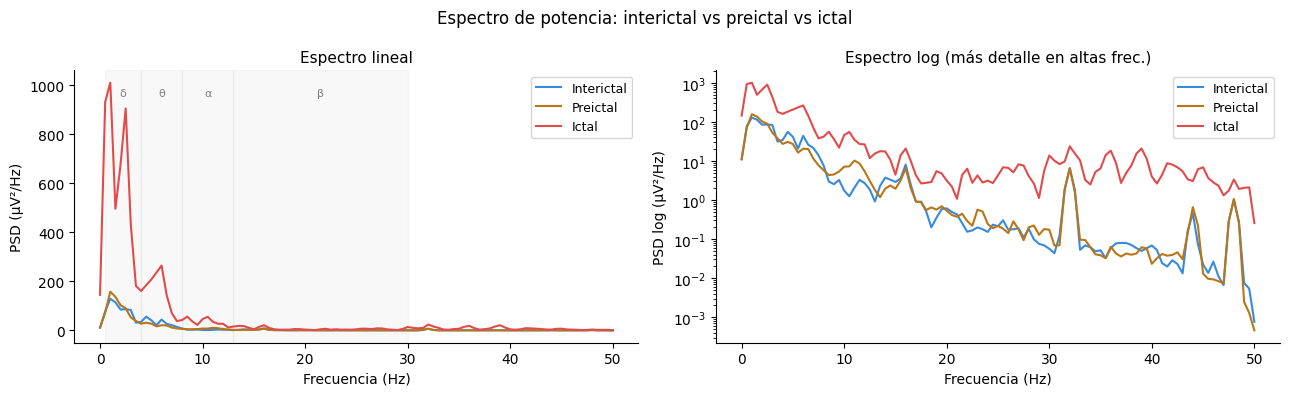

💡 El pico de delta/theta durante la crisis es el patrón más característico
   El preictal es sutil — ahí es donde ML puede ayudar al ojo humano


In [6]:
# Comparar espectro medio por clase en canal FP1 (frontal)
fs   = int(raw.info['sfreq'])
data = raw.get_data() * 1e6
win  = WINDOW_SEC * fs

sz_start, sz_end = FILES_WITH_SEIZURES['chb01_03.edf'][0]

# Segmento ictal
ictal_seg = data[0, sz_start*fs : (sz_start+WINDOW_SEC)*fs]
# Segmento interictal (1h antes)
inter_start = max(0, sz_start - INTERICTAL_BUFFER)
inter_seg   = data[0, inter_start*fs : (inter_start+WINDOW_SEC)*fs]
# Segmento preictal
pre_start = sz_start - PREICTAL_MIN*60
pre_seg   = data[0, pre_start*fs : (pre_start+WINDOW_SEC)*fs]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Espectro de potencia: interictal vs preictal vs ictal', fontsize=12)

COLORS_EP = {'Interictal':'#378ADD', 'Preictal':'#BA7517', 'Ictal':'#E24B4A'}

# Espectro lineal
for seg, name in [(inter_seg,'Interictal'),(pre_seg,'Preictal'),(ictal_seg,'Ictal')]:
    if len(seg) < win: continue
    f, p = welch(seg, fs=fs, nperseg=fs*2)
    mask = f <= 50
    axes[0].plot(f[mask], p[mask], lw=1.5,
                 color=COLORS_EP[name], label=name)
axes[0].set_xlabel('Frecuencia (Hz)', fontsize=10)
axes[0].set_ylabel('PSD (µV²/Hz)', fontsize=10)
axes[0].set_title('Espectro lineal', fontsize=11)
axes[0].legend(fontsize=9)
axes[0].spines[['top','right']].set_visible(False)
for flo, fhi, bname in [(0.5,4,'δ'),(4,8,'θ'),(8,13,'α'),(13,30,'β')]:
    axes[0].axvspan(flo, fhi, alpha=0.05, color='gray')
    axes[0].text((flo+fhi)/2, axes[0].get_ylim()[1]*0.9, bname,
                ha='center', fontsize=8, color='gray')

# Espectro log
for seg, name in [(inter_seg,'Interictal'),(pre_seg,'Preictal'),(ictal_seg,'Ictal')]:
    if len(seg) < win: continue
    f, p = welch(seg, fs=fs, nperseg=fs*2)
    mask = f <= 50
    axes[1].semilogy(f[mask], p[mask], lw=1.5,
                     color=COLORS_EP[name], label=name)
axes[1].set_xlabel('Frecuencia (Hz)', fontsize=10)
axes[1].set_ylabel('PSD log (µV²/Hz)', fontsize=10)
axes[1].set_title('Espectro log (más detalle en altas frec.)', fontsize=11)
axes[1].legend(fontsize=9)
axes[1].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('epilepsy_spectrum.png', dpi=120, bbox_inches='tight')
plt.show()
print('💡 El pico de delta/theta durante la crisis es el patrón más característico')
print('   El preictal es sutil — ahí es donde ML puede ayudar al ojo humano')

In [8]:
pipelines = {
    'Random Forest': Pipeline([
        ('scaler', StandardScaler()),
        ('clf',    RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1))
    ]),
    'SVM RBF': Pipeline([
        ('scaler', StandardScaler()),
        ('clf',    SVC(kernel='rbf', C=10, gamma='scale', probability=True))
    ]),
    'Gradient Boost': Pipeline([
        ('scaler', StandardScaler()),
        ('clf',    GradientBoostingClassifier(n_estimators=100, random_state=42))
    ])
}
print('✅ Pipelines definidos')

✅ Pipelines definidos


## 7. Clasificación: Interictal vs Ictal (problema binario)

Empezamos con el caso más sencillo — detectar si hay crisis o no.

In [9]:
# Filtrar solo interictal (0) e ictal (2)
mask_bin = y_all != 1
X_bin = X_all[mask_bin]
y_bin = (y_all[mask_bin] == 2).astype(int)

n_ictal = (y_bin == 1).sum()
n_inter = (y_bin == 0).sum()
print(f'Antes de balancear: interictal={n_inter}, ictal={n_ictal}')

# Ratio 3:1
idx_ictal = np.where(y_bin == 1)[0]
idx_inter = np.where(y_bin == 0)[0]
idx_inter_sub = np.random.choice(idx_inter, min(n_inter, n_ictal*3), replace=False)
idx_bal = np.concatenate([idx_ictal, idx_inter_sub])
np.random.shuffle(idx_bal)

X_bal = X_bin[idx_bal]
y_bal = y_bin[idx_bal]
print(f'Después de balancear: interictal={(y_bal==0).sum()}, ictal={(y_bal==1).sum()}')

# CV con menos folds si hay pocos datos
n_min_class = min(np.bincount(y_bal))
n_splits = min(5, n_min_class)
print(f'Usando {n_splits} folds (mínimo por clase: {n_min_class})')
cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

results_bin = {}
for name, pipe in pipelines.items():
    scores = cross_val_score(pipe, X_bal, y_bal, cv=cv,
                              scoring='f1', n_jobs=-1)
    results_bin[name] = scores
    bar = '█' * int(scores.mean()*20)
    print(f'  {name:<20} F1={scores.mean():.3f} ± {scores.std():.3f}  {bar}')

best_bin = max(results_bin, key=lambda k: results_bin[k].mean())
print(f'\n🏆 Mejor: {best_bin}')

Antes de balancear: interictal=2339, ictal=58
Después de balancear: interictal=174, ictal=58
Usando 5 folds (mínimo por clase: 58)
  Random Forest        F1=0.944 ± 0.055  ██████████████████
  SVM RBF              F1=0.963 ± 0.055  ███████████████████
  Gradient Boost       F1=0.924 ± 0.078  ██████████████████

🏆 Mejor: SVM RBF


## 8. Clasificación: Detección preictal

El problema clínicamente más valioso — y más difícil.
Clasificamos interictal (0) vs preictal (1).

In [10]:
# Interictal vs Preictal
mask_pre = y_all != 2
X_pre = X_all[mask_pre]
y_pre = y_all[mask_pre]  # 0=interictal, 1=preictal

n_pre   = (y_pre == 1).sum()
n_inter = (y_pre == 0).sum()
print(f'Interictal={n_inter}, Preictal={n_pre}')

if n_pre > 0:
    # Balancear 2:1
    idx_pre   = np.where(y_pre == 1)[0]
    idx_inter = np.where(y_pre == 0)[0]
    idx_inter_sub = np.random.choice(idx_inter, min(n_inter, n_pre*2), replace=False)
    idx_bal_pre   = np.concatenate([idx_pre, idx_inter_sub])
    np.random.shuffle(idx_bal_pre)

    X_pre_bal = X_pre[idx_bal_pre]
    y_pre_bal = y_pre[idx_bal_pre]

    print('\n🔬 Clasificación: Interictal vs Preictal (5 min antes de crisis)\n')
    results_pre = {}
    for name, pipe in pipelines.items():
        scores = cross_val_score(pipe, X_pre_bal, y_pre_bal, cv=cv,
                                  scoring='f1', n_jobs=-1)
        results_pre[name] = scores
        bar = '█' * int(scores.mean()*20)
        print(f'  {name:<20} F1={scores.mean():.3f} ± {scores.std():.3f}  {bar}')
    print('\n💡 El preictal es sutil — F1 < ictal es normal y esperado')
else:
    print('⚠️  No hay suficientes segmentos preictales — descarga más archivos')
    results_pre = {}

Interictal=2339, Preictal=292

🔬 Clasificación: Interictal vs Preictal (5 min antes de crisis)

  Random Forest        F1=0.808 ± 0.057  ████████████████
  SVM RBF              F1=0.883 ± 0.030  █████████████████
  Gradient Boost       F1=0.798 ± 0.039  ███████████████

💡 El preictal es sutil — F1 < ictal es normal y esperado


## 9. Análisis detallado y curva ROC

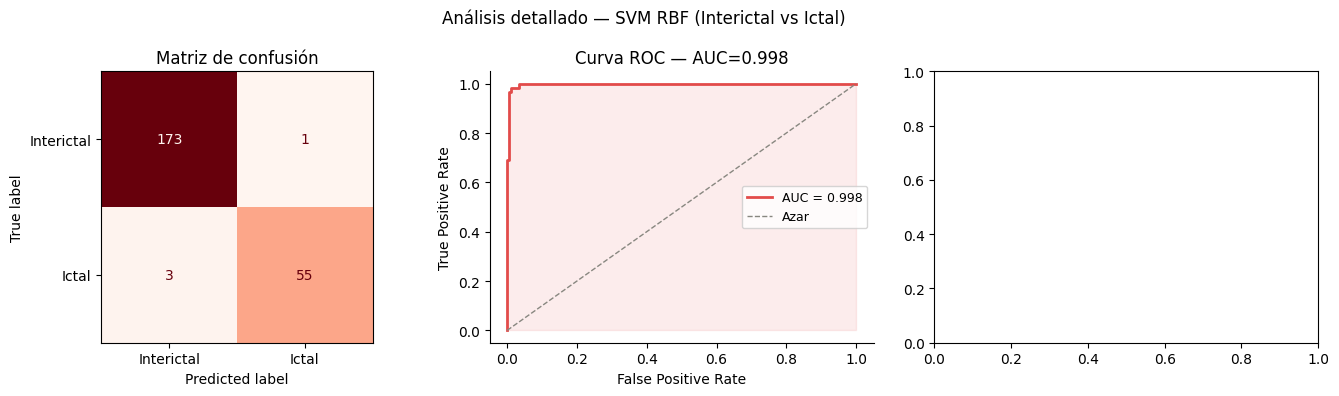


📋 Reporte completo:
              precision    recall  f1-score   support

  Interictal       0.98      0.99      0.99       174
       Ictal       0.98      0.95      0.96        58

    accuracy                           0.98       232
   macro avg       0.98      0.97      0.98       232
weighted avg       0.98      0.98      0.98       232



In [11]:
best_pipe = pipelines[best_bin]
best_pipe.fit(X_bal, y_bal)
y_pred = cross_val_predict(best_pipe, X_bal, y_bal, cv=cv)
y_prob = cross_val_predict(best_pipe, X_bal, y_bal, cv=cv, method='predict_proba')[:,1]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle(f'Análisis detallado — {best_bin} (Interictal vs Ictal)', fontsize=12)

# Confusion matrix
cm = confusion_matrix(y_bal, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['Interictal','Ictal']).plot(
    ax=axes[0], colorbar=False, cmap='Reds')
axes[0].set_title('Matriz de confusión')

# ROC curve
fpr, tpr, _ = roc_curve(y_bal, y_prob)
roc_auc     = auc(fpr, tpr)
axes[1].plot(fpr, tpr, color='#E24B4A', lw=2, label=f'AUC = {roc_auc:.3f}')
axes[1].plot([0,1],[0,1], color='#888780', lw=1, ls='--', label='Azar')
axes[1].fill_between(fpr, tpr, alpha=0.1, color='#E24B4A')
axes[1].set_xlabel('False Positive Rate', fontsize=10)
axes[1].set_ylabel('True Positive Rate', fontsize=10)
axes[1].set_title(f'Curva ROC — AUC={roc_auc:.3f}')
axes[1].legend(fontsize=9)
axes[1].spines[['top','right']].set_visible(False)

# Feature importance
rf = best_pipe.named_steps['clf']
if hasattr(rf, 'feature_importances_'):
    imp = rf.feature_importances_
    n_bands   = len(BANDS)
    n_stat    = 3
    n_per_ch  = n_bands + n_stat
    n_ch_data = X_bal.shape[1] // n_per_ch

    # Agrupar por tipo de feature
    band_names = list(BANDS.keys()) + ['std','mean_abs','line_len']
    feat_groups = np.zeros(n_per_ch)
    for i in range(n_ch_data):
        feat_groups += imp[i*n_per_ch:(i+1)*n_per_ch]
    feat_groups /= n_ch_data

    axes[2].bar(range(n_per_ch), feat_groups,
                color=['#534AB7']*n_bands + ['#639922']*n_stat, alpha=0.8)
    axes[2].set_xticks(range(n_per_ch))
    axes[2].set_xticklabels(band_names, rotation=30, ha='right', fontsize=9)
    axes[2].set_title('Importancia por tipo de feature\n(media sobre canales)')
    axes[2].set_ylabel('Importancia')
    axes[2].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('epilepsy_results.png', dpi=120, bbox_inches='tight')
plt.show()

print(f'\n📋 Reporte completo:')
print(classification_report(y_bal, y_pred,
                              target_names=['Interictal','Ictal']))

## 10. Guardar y próximos pasos

In [12]:
import joblib
joblib.dump(best_pipe, 'epilepsy_detector.pkl')
print('💾 Modelo guardado: epilepsy_detector.pkl')

print('''
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
RESUMEN — Pipeline epilepsia v1
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Dataset:    CHB-MIT chb01 (epilepsia focal pediátrica)
Features:   Potencia espectral (5 bandas) + estadísticos
            + line length (sensible a spikes)
Clases:     Interictal / Preictal / Ictal
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Próximos pasos:

v2 — Más pacientes (chb02, chb03...)
     Ventanas más cortas para preictal fino
     LSTM / Transformer temporal

v3 — EEGNet adaptado a detección epiléptica
     Transfer learning entre pacientes

v4 — Sistema de alerta: umbral adaptativo
     + estimación de tiempo hasta crisis
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
''')

💾 Modelo guardado: epilepsy_detector.pkl

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
RESUMEN — Pipeline epilepsia v1
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Dataset:    CHB-MIT chb01 (epilepsia focal pediátrica)
Features:   Potencia espectral (5 bandas) + estadísticos
            + line length (sensible a spikes)
Clases:     Interictal / Preictal / Ictal
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Próximos pasos:

v2 — Más pacientes (chb02, chb03...)
     Ventanas más cortas para preictal fino
     LSTM / Transformer temporal

v3 — EEGNet adaptado a detección epiléptica
     Transfer learning entre pacientes

v4 — Sistema de alerta: umbral adaptativo
     + estimación de tiempo hasta crisis
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━



In [1]:
import os
print(os.path.expanduser('~/chbmit_data/chb01'))

C:\Users\Drizzy/chbmit_data/chb01
